# FolpsD cross-spectrum damping modes

This notebook is a compact NumPy example for the new equal-time two-tracer
cross-spectrum damping controls. It uses `model="FOLPSD"` with the public
power-spectrum damping choices and compares the two cross damping modes:

- `cross_damping_mode="single"`: use one pair-level value, `X_FoG_ab = cross_nuisance_ab[-1]`.
- `cross_damping_mode="geometric"`: use the tracer-level values from `pars_a[-1]` and `pars_b[-1]` through `sqrt(W_A W_B)`.

The parameter values below are illustrative only. There are no benchmark or
timing cells in this notebook.


## Imports and setup


In [1]:
import os
import sys
import tempfile
from pathlib import Path

os.environ["FOLPS_BACKEND"] = "numpy"
sys.dont_write_bytecode = True

_mpl_config_dir = tempfile.TemporaryDirectory(prefix="folps_cross_damping_mpl_")
os.environ["MPLCONFIGDIR"] = _mpl_config_dir.name

import matplotlib.pyplot as plt
import numpy as np

from folps import (
    MatrixCalculator,
    NonLinearPowerSpectrumCalculator,
    RSDMultipolesPowerSpectrumCalculator,
)


Matplotlib is building the font cache; this may take a moment.


✅ Using NumPy with CPU.


## Build the loop tables


In [2]:
def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "folps" / "__init__.py").exists() and (candidate / "folps" / "inputpkT.txt").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FolpsD repository root.")

repo_root = find_repo_root(Path.cwd())
os.chdir(repo_root)
input_power_path = Path("folps/inputpkT.txt")
matrix_dir = Path("folps/output_matrices")
matrix_cache = matrix_dir / "matrices_nfftlog128_Afull-True_use_TNS-False.npy"
if not matrix_cache.exists():
    raise FileNotFoundError(f"Missing matrix cache: {matrix_cache}")

k_input, p_input = np.loadtxt(input_power_path, unpack=True)
cosmo = {
    "z": 0.3,
    "h": 0.6711,
    "Omega_m": 0.3211636237981114,
    "f0": np.float64(0.6880638641959066),
    "fnu": 0.004453689063655854,
}

matrix = MatrixCalculator(A_full=True, use_TNS_model=False, save_dir=str(matrix_dir))
nonlinear = NonLinearPowerSpectrumCalculator(
    mmatrices=matrix.get_mmatrices(),
    kernels="fk",
    **cosmo,
)
table, table_now = nonlinear.calculate_loop_table(
    k=k_input,
    pklin=p_input,
    cosmo=None,
    **cosmo,
)

print("Repository root: .")
print(f"FOLPS k grid samples: {len(table[0])}")


Loading matrices from folps/output_matrices/matrices_nfftlog128_Afull-True_use_TNS-False.npy
Repository root: .
FOLPS k grid samples: 120


## Define two tracers and pair-level cross nuisance parameters


In [3]:
def coevolution_bK2(b1):
    return -2.0 / 7.0 * (b1 - 1.0)


def coevolution_btd(b1):
    return 23.0 / 42.0 * (b1 - 1.0)


def priordoc_params(b1, b2, x_fog, nuisance):
    return [
        b1,
        b2,
        coevolution_bK2(b1),
        coevolution_btd(b1),
        *nuisance[:-1],
        x_fog,
    ]

# Last entry is X_FoG for each auto-spectrum tracer parameter vector.
nuisance_a = [0.7, -1.3, 0.2, 0.0, 0.015, -0.45, 4800.0, 0.0]
nuisance_b = [0.2, -0.4, 0.1, 0.0, 0.0, 0.0, 3600.0, 0.0]
pars_a = priordoc_params(1.645, 0.20, 0.30, nuisance_a)
pars_b = priordoc_params(1.10, -0.23, 6.00, nuisance_b)

# Eight pair-level cross nuisance values. The final value is X_FoG_ab.
cross_nuisance_ab = [
    0.4,     # alpha0_ab
    -0.9,    # alpha2_ab
    0.15,    # alpha4_ab
    0.0,     # ctilde_ab
    0.01,    # alphashot0_ab
    -0.2,    # alphashot2_ab
    3600.0,  # PshotP_ab
    1.20,    # X_FoG_ab
]

print(f"X_FoG_A  = {pars_a[-1]:.2f}")
print(f"X_FoG_B  = {pars_b[-1]:.2f}")
print(f"X_FoG_ab = {cross_nuisance_ab[-1]:.2f}")


X_FoG_A  = 0.30
X_FoG_B  = 6.00
X_FoG_ab = 1.20


## Compute single and geometric cross damping modes

The default is `cross_damping_mode="single"`, so omitting the keyword should match the explicit single-mode call. The example uses `damping="vdg"`; the next section checks that `"exp"` and `"lor"` are accepted too.


In [4]:
ells = (0, 2, 4)
k_output = np.linspace(0.01, 0.2, 80)
calculator = RSDMultipolesPowerSpectrumCalculator(model="FOLPSD")

common_kwargs = dict(
    kobs=k_output,
    qpar=1.0,
    qper=1.0,
    pars=pars_a,
    table=table,
    table_now=table_now,
    bias_scheme="priordoc",
    bias_scheme_b="priordoc",
    damping="vdg",
    nmu=10,
    ells=ells,
    IR_resummation=True,
    pars_b=pars_b,
    cross_nuisance=cross_nuisance_ab,
)

pells_single = calculator.get_rsd_pkell(cross_damping_mode="single", **common_kwargs)
pells_default = calculator.get_rsd_pkell(**common_kwargs)
pells_geometric = calculator.get_rsd_pkell(cross_damping_mode="geometric", **common_kwargs)

assert np.allclose(pells_default, pells_single)
print(f"default minus explicit single max abs: {np.max(np.abs(pells_default - pells_single)):.3e}")
print(f"single/geometric P0 max abs difference: {np.max(np.abs(pells_geometric[0] - pells_single[0])):.3e}")


default minus explicit single max abs: 0.000e+00
single/geometric P0 max abs difference: 2.378e+01


## Check which FoG values each mode uses


In [5]:
def replace_last(values, new_value):
    updated = list(values)
    updated[-1] = new_value
    return updated

# Single mode ignores tracer-level X_FoG_A and X_FoG_B while X_FoG_ab is fixed.
pars_a_changed_x = replace_last(pars_a, 7.00)
pars_b_changed_x = replace_last(pars_b, 0.15)
single_changed_tracers = calculator.get_rsd_pkell(
    cross_damping_mode="single",
    **{**common_kwargs, "pars": pars_a_changed_x, "pars_b": pars_b_changed_x},
)

# Single mode responds to the pair-level X_FoG_ab.
cross_nuisance_changed_x = replace_last(cross_nuisance_ab, 8.00)
single_changed_pair = calculator.get_rsd_pkell(
    cross_damping_mode="single",
    **{**common_kwargs, "cross_nuisance": cross_nuisance_changed_x},
)

# Geometric mode ignores X_FoG_ab while tracer-level values are fixed.
geometric_changed_pair = calculator.get_rsd_pkell(
    cross_damping_mode="geometric",
    **{**common_kwargs, "cross_nuisance": cross_nuisance_changed_x},
)

# Geometric mode responds to tracer-level X_FoG_A or X_FoG_B.
geometric_changed_tracers = calculator.get_rsd_pkell(
    cross_damping_mode="geometric",
    **{**common_kwargs, "pars": pars_a_changed_x, "pars_b": pars_b},
)

print(f"single, changed tracer X_FoG max abs: {np.max(np.abs(single_changed_tracers - pells_single)):.3e}")
print(f"single, changed X_FoG_ab max abs:     {np.max(np.abs(single_changed_pair - pells_single)):.3e}")
print(f"geometric, changed X_FoG_ab max abs:  {np.max(np.abs(geometric_changed_pair - pells_geometric)):.3e}")
print(f"geometric, changed X_FoG_A max abs:   {np.max(np.abs(geometric_changed_tracers - pells_geometric)):.3e}")


single, changed tracer X_FoG max abs: 0.000e+00
single, changed X_FoG_ab max abs:     1.587e+02
geometric, changed X_FoG_ab max abs:  0.000e+00
geometric, changed X_FoG_A max abs:   6.206e+01


## Equal-X and no-damping limits


In [6]:
pars_a_equal_x = replace_last(pars_a, 2.40)
pars_b_equal_x = replace_last(pars_b, 2.40)
cross_equal_x = replace_last(cross_nuisance_ab, 2.40)
common_equal_x = {**common_kwargs, "pars": pars_a_equal_x, "pars_b": pars_b_equal_x, "cross_nuisance": cross_equal_x}

equal_single = calculator.get_rsd_pkell(cross_damping_mode="single", **common_equal_x)
equal_geometric = calculator.get_rsd_pkell(cross_damping_mode="geometric", **common_equal_x)

no_damping_single = calculator.get_rsd_pkell(
    cross_damping_mode="single",
    **{**common_kwargs, "damping": None},
)
no_damping_geometric = calculator.get_rsd_pkell(
    cross_damping_mode="geometric",
    **{**common_kwargs, "damping": None},
)

print(f"equal-X single/geometric max abs: {np.max(np.abs(equal_geometric - equal_single)):.3e}")
print(f"damping=None single/geometric max abs: {np.max(np.abs(no_damping_geometric - no_damping_single)):.3e}")


equal-X single/geometric max abs: 0.000e+00
damping=None single/geometric max abs: 0.000e+00


## Supported damping names


In [7]:
summary_rows = []
for damping_name in ("exp", "lor", "vdg"):
    single = calculator.get_rsd_pkell(
        cross_damping_mode="single",
        **{**common_kwargs, "damping": damping_name},
    )
    geometric = calculator.get_rsd_pkell(
        cross_damping_mode="geometric",
        **{**common_kwargs, "damping": damping_name},
    )
    with np.errstate(divide="ignore", invalid="ignore"):
        frac = np.divide(
            geometric - single,
            single,
            out=np.full_like(single, np.nan, dtype=float),
            where=np.abs(single) > 1.0e-10 * max(np.max(np.abs(single)), 1.0),
        )
    summary_rows.append((damping_name, np.nanmax(np.abs(frac))))

for damping_name, max_frac in summary_rows:
    print(f"{damping_name:>3s}: max stable |geometric/single - 1| = {max_frac:.3e}")


exp: max stable |geometric/single - 1| = 5.214e-01
lor: max stable |geometric/single - 1| = 2.185e-01
vdg: max stable |geometric/single - 1| = 1.657e-02


## Plot the VDG damping-mode comparison


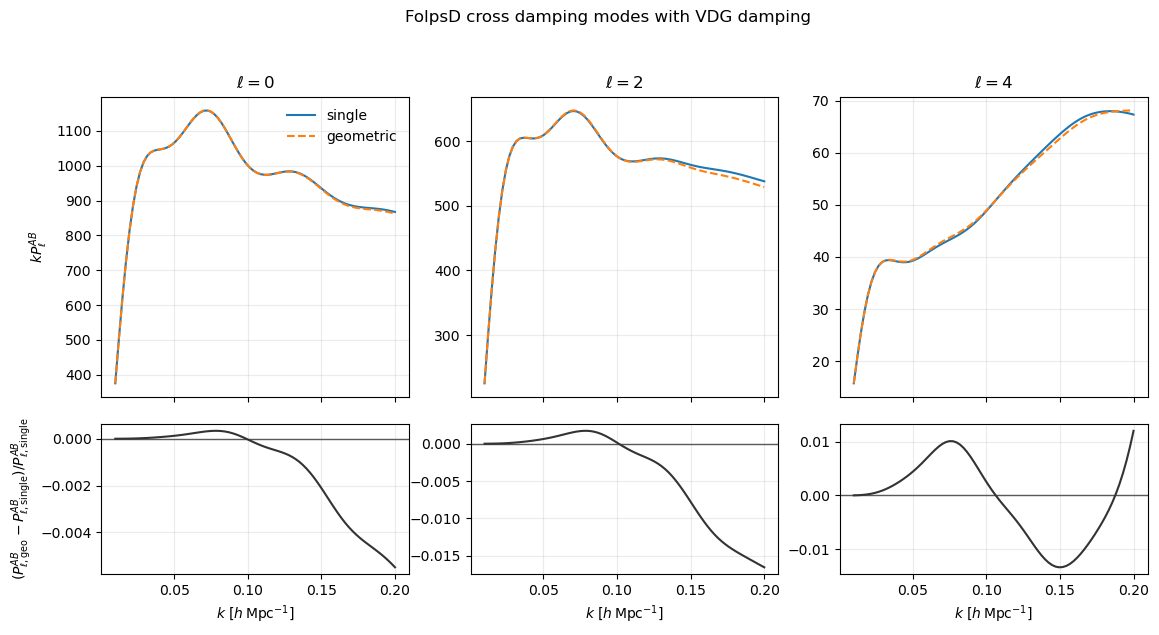

In [8]:
with np.errstate(divide="ignore", invalid="ignore"):
    frac = np.divide(
        pells_geometric - pells_single,
        pells_single,
        out=np.full_like(pells_single, np.nan, dtype=float),
        where=np.abs(pells_single) > 1.0e-10 * max(np.max(np.abs(pells_single)), 1.0),
    )

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13.5, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0], "hspace": 0.12},
)
for ell_index, ell in enumerate(ells):
    axes[0, ell_index].plot(k_output, k_output * pells_single[ell_index], label="single", color="C0")
    axes[0, ell_index].plot(k_output, k_output * pells_geometric[ell_index], label="geometric", color="C1", ls="--")
    axes[1, ell_index].axhline(0.0, color="0.35", lw=1.0)
    axes[1, ell_index].plot(k_output, frac[ell_index], color="0.2")
    axes[0, ell_index].set_title(rf"$\ell={ell}$")
    axes[1, ell_index].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
    if ell_index == 0:
        axes[0, ell_index].set_ylabel(r"$kP_\ell^{AB}$")
        axes[1, ell_index].set_ylabel(r"$(P_{\ell,\rm geo}^{AB}-P_{\ell,\rm single}^{AB})/P_{\ell,\rm single}^{AB}$")
        axes[0, ell_index].legend(frameon=False)
    for row in range(2):
        axes[row, ell_index].grid(alpha=0.25)

fig.suptitle("FolpsD cross damping modes with VDG damping", y=1.02)
plt.show()


## Takeaway

Use `cross_damping_mode="single"` when the cross spectrum should have one
pair-level damping nuisance parameter, `X_FoG_ab`. Use
`cross_damping_mode="geometric"` when the cross damping should be built from
the two tracer-level damping factors. Both modes keep the same eight-entry
`cross_nuisance_ab` vector and leave the cross stochastic parameterization
unchanged.
